In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
trades_df = pd.read_csv("../Data/historical_data.csv")
sentiment_df = pd.read_csv("../Data/fear_greed_index.csv")

In [3]:
print("Trader Data Shape:", trades_df.shape)
print("Sentiment Data Shape:", sentiment_df.shape)

Trader Data Shape: (211224, 16)
Sentiment Data Shape: (2644, 4)


In [4]:
print(trades_df.columns)

print()

print(sentiment_df.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')

Index(['timestamp', 'value', 'classification', 'date'], dtype='str')


In [5]:
print(trades_df["Timestamp"].head())

0    1.730000e+12
1    1.730000e+12
2    1.730000e+12
3    1.730000e+12
4    1.730000e+12
Name: Timestamp, dtype: float64


In [6]:
print(sentiment_df["timestamp"].head())

0    1517463000
1    1517549400
2    1517635800
3    1517722200
4    1517808600
Name: timestamp, dtype: int64


In [7]:
# Convert trader timestamp (milliseconds)
trades_df["Timestamp"] = pd.to_datetime(
    trades_df["Timestamp"].astype("int64"),
    unit="ms"
)

# Convert sentiment timestamp (seconds)
sentiment_df["timestamp"] = pd.to_datetime(
    sentiment_df["timestamp"],
    unit="s"
)

In [8]:
print(trades_df["Timestamp"].head())

print()

print(sentiment_df["timestamp"].head())

0   2024-10-27 03:33:20
1   2024-10-27 03:33:20
2   2024-10-27 03:33:20
3   2024-10-27 03:33:20
4   2024-10-27 03:33:20
Name: Timestamp, dtype: datetime64[ms]

0   2018-02-01 05:30:00
1   2018-02-02 05:30:00
2   2018-02-03 05:30:00
3   2018-02-04 05:30:00
4   2018-02-05 05:30:00
Name: timestamp, dtype: datetime64[s]


In [9]:
print(repr(trades_df["Timestamp"].iloc[0]))

Timestamp('2024-10-27 03:33:20')


In [10]:
trades_df["date"] = trades_df["Timestamp"].dt.date
sentiment_df["date"] = sentiment_df["timestamp"].dt.date

In [11]:
print(trades_df[["Timestamp", "date"]].head())
print()
print(sentiment_df[["timestamp", "date"]].head())

            Timestamp        date
0 2024-10-27 03:33:20  2024-10-27
1 2024-10-27 03:33:20  2024-10-27
2 2024-10-27 03:33:20  2024-10-27
3 2024-10-27 03:33:20  2024-10-27
4 2024-10-27 03:33:20  2024-10-27

            timestamp        date
0 2018-02-01 05:30:00  2018-02-01
1 2018-02-02 05:30:00  2018-02-02
2 2018-02-03 05:30:00  2018-02-03
3 2018-02-04 05:30:00  2018-02-04
4 2018-02-05 05:30:00  2018-02-05


In [12]:
merged_df = pd.merge(
    trades_df,
    sentiment_df[["date", "classification", "value"]],
    on="date",
    how="left"
)

print("Merged Shape:", merged_df.shape)
merged_df.head()

Merged Shape: (211224, 19)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,Greed,74.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,Greed,74.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,Greed,74.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,Greed,74.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,Greed,74.0


In [13]:
print(merged_df[["date", "classification", "value"]].head(10))

         date classification  value
0  2024-10-27          Greed   74.0
1  2024-10-27          Greed   74.0
2  2024-10-27          Greed   74.0
3  2024-10-27          Greed   74.0
4  2024-10-27          Greed   74.0
5  2024-10-27          Greed   74.0
6  2024-10-27          Greed   74.0
7  2024-10-27          Greed   74.0
8  2024-10-27          Greed   74.0
9  2024-10-27          Greed   74.0


In [14]:
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  str           
 1   Coin              211224 non-null  str           
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  str           
 6   Timestamp IST     211224 non-null  str           
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  str           
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  str           
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trade ID       

In [15]:
merged_df.isnull().sum()

Account                 0
Coin                    0
Execution Price         0
Size Tokens             0
Size USD                0
Side                    0
Timestamp IST           0
Start Position          0
Direction               0
Closed PnL              0
Transaction Hash        0
Order ID                0
Crossed                 0
Fee                     0
Trade ID                0
Timestamp               0
date                    0
classification      26961
value               26961
dtype: int64

In [16]:
merged_df["classification"].value_counts()

classification
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64

In [17]:
merged_df.groupby("classification")["Closed PnL"].mean().sort_values()

classification
Neutral          22.229713
Extreme Greed    25.418772
Fear             50.047622
Greed            87.894859
Name: Closed PnL, dtype: float64

In [18]:
merged_df.groupby("classification").size()

classification
Extreme Greed      6962
Fear             133871
Greed             36289
Neutral            7141
dtype: int64

In [19]:
merged_df.groupby("classification")["Size USD"].mean()

classification
Extreme Greed    5660.265764
Fear             5259.977837
Greed            3182.883845
Neutral          3058.848110
Name: Size USD, dtype: float64

In [20]:
merged_df["Profit"] = merged_df["Closed PnL"] > 0

In [21]:
merged_df.groupby("classification")["Profit"].mean() * 100

classification
Extreme Greed    49.008905
Fear             41.514592
Greed            44.647138
Neutral          31.718247
Name: Profit, dtype: float64

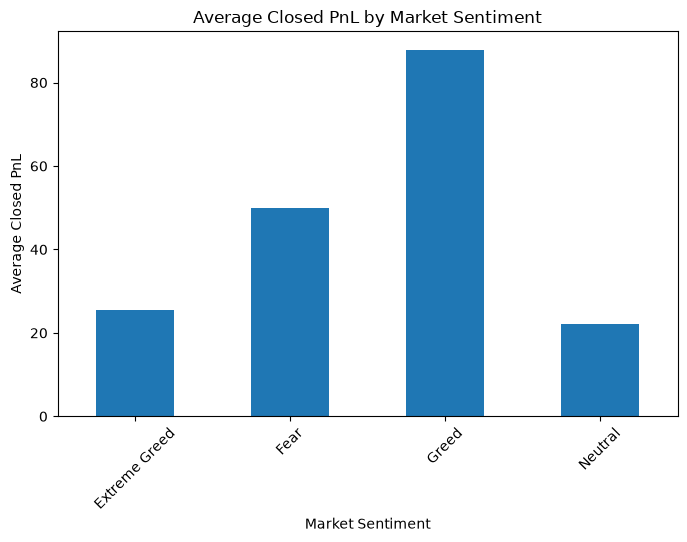

In [22]:
import matplotlib.pyplot as plt

merged_df.groupby("classification")["Closed PnL"].mean().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=45)
plt.show()

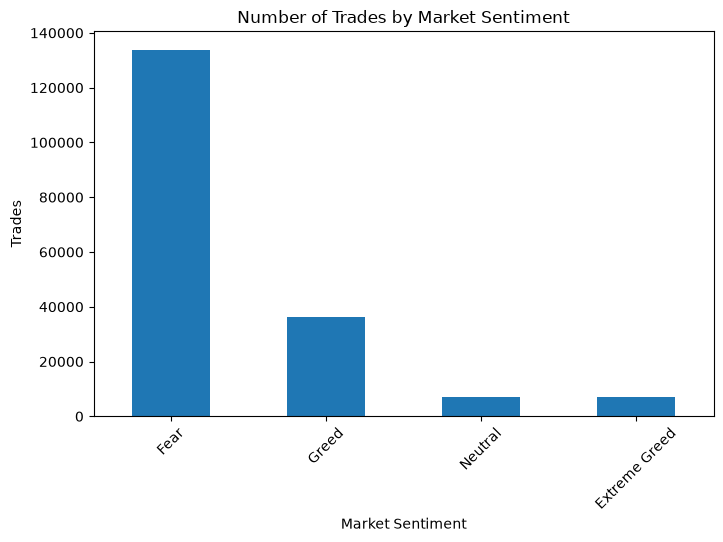

In [23]:
merged_df["classification"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Trades")
plt.xticks(rotation=45)
plt.show()

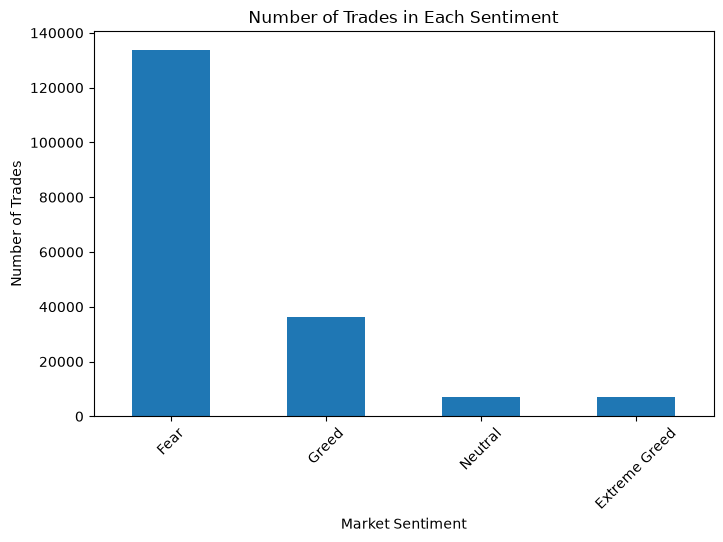

In [24]:
import matplotlib.pyplot as plt

merged_df["classification"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Number of Trades in Each Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)
plt.show()

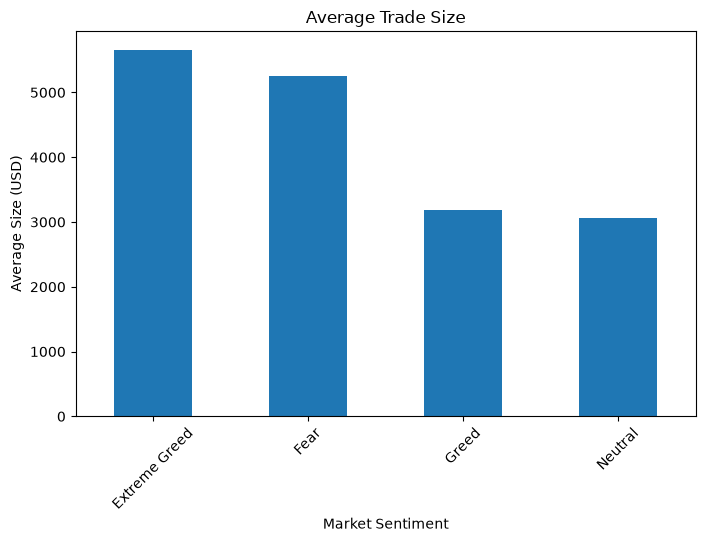

In [25]:
merged_df.groupby("classification")["Size USD"].mean().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Trade Size")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Size (USD)")
plt.xticks(rotation=45)
plt.show()

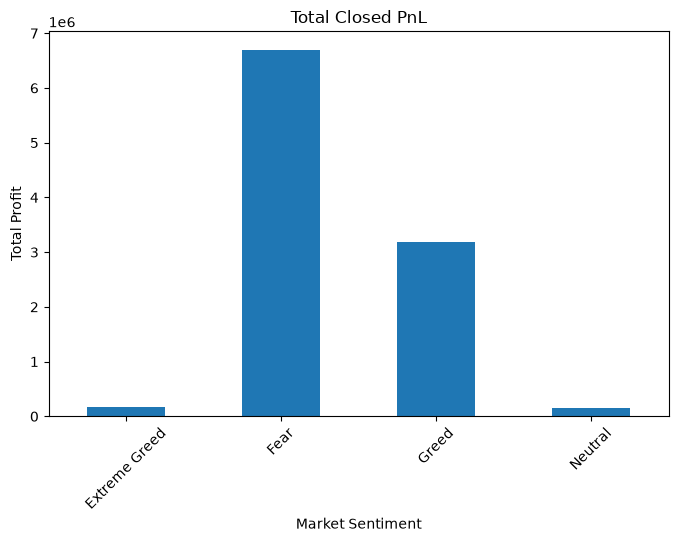

In [26]:
merged_df.groupby("classification")["Closed PnL"].sum().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Total Closed PnL")
plt.xlabel("Market Sentiment")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.show()

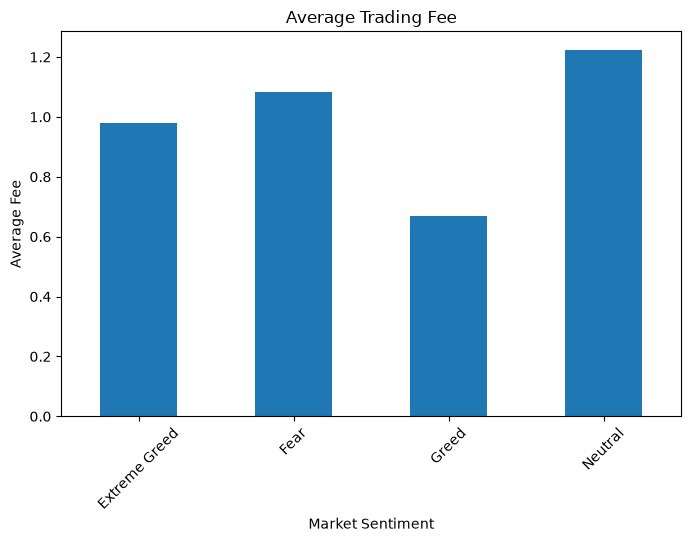

In [27]:
merged_df.groupby("classification")["Fee"].mean().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Trading Fee")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Fee")
plt.xticks(rotation=45)
plt.show()

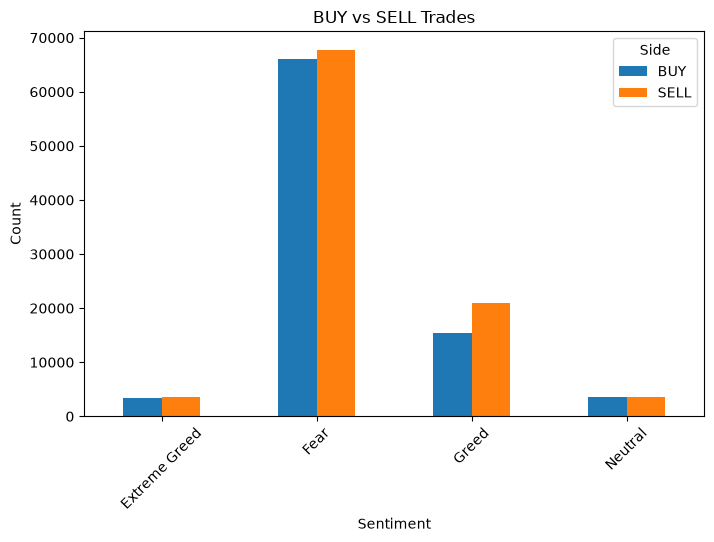

In [28]:
import pandas as pd

pd.crosstab(
    merged_df["classification"],
    merged_df["Side"]
).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("BUY vs SELL Trades")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

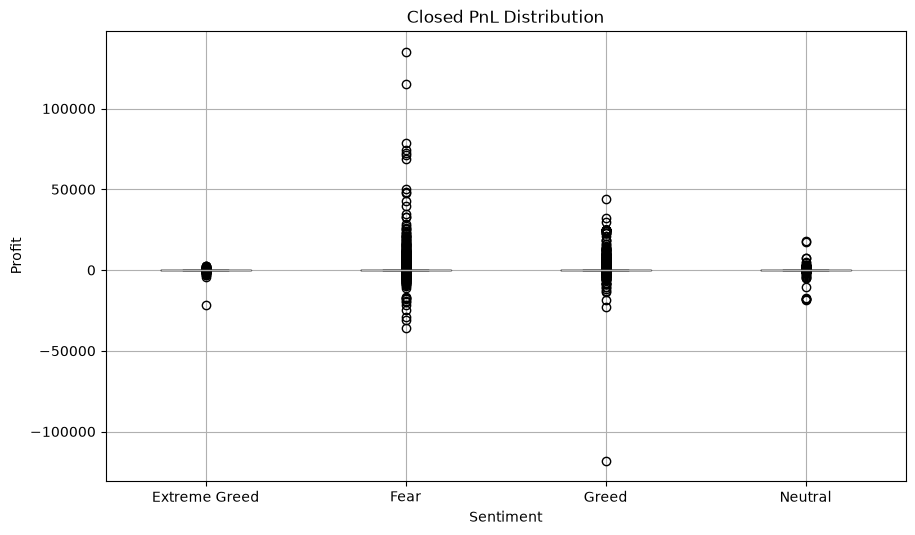

In [29]:
merged_df.boxplot(
    column="Closed PnL",
    by="classification",
    figsize=(10,6)
)

plt.title("Closed PnL Distribution")
plt.suptitle("")
plt.xlabel("Sentiment")
plt.ylabel("Profit")
plt.show()

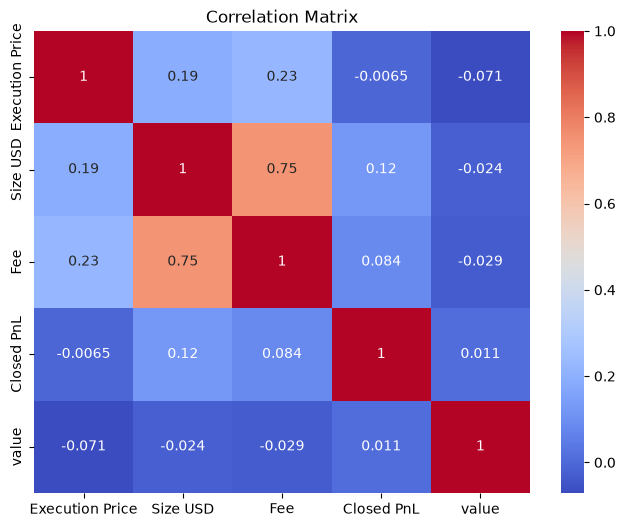

In [30]:
import seaborn as sns

corr = merged_df[
    ["Execution Price",
     "Size USD",
     "Fee",
     "Closed PnL",
     "value"]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

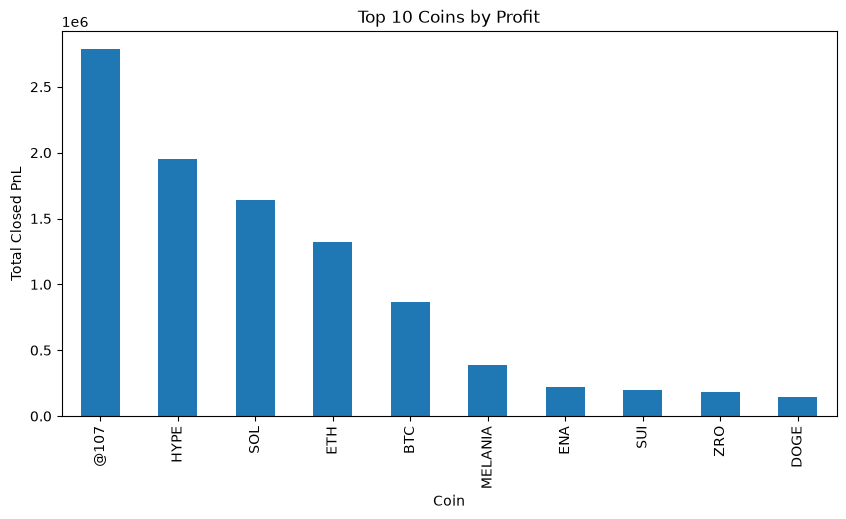

In [31]:
merged_df.groupby("Coin")["Closed PnL"] \
         .sum() \
         .sort_values(ascending=False) \
         .head(10) \
         .plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Coins by Profit")
plt.ylabel("Total Closed PnL")
plt.show()

In [32]:
merged_df = merged_df.dropna(subset=["classification", "value"])

In [33]:
merged_df.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
date                0
classification      0
value               0
Profit              0
dtype: int64

In [34]:
merged_df["Profit"] = (merged_df["Closed PnL"] > 0).astype(int)

In [35]:
merged_df[["Closed PnL", "Profit"]].head(10)

,Closed PnL,Profit
0,0.0,0
1,0.0,0
2,0.0,0
3,0.0,0
4,0.0,0
5,0.0,0
6,0.0,0
7,0.0,0
8,0.0,0
9,0.0,0


In [36]:
merged_df[["Closed PnL", "Profit"]].sample(10)

,Closed PnL,Profit
76244,32.918460,1
83694,0.000000,0
155573,6.815536,1
61129,46.658131,1
164956,-11.499361,0
201885,0.000000,0
102112,-200.644910,0
127752,0.000000,0
190947,0.000000,0
170956,0.000000,0


In [38]:
merged_df["Profit"].value_counts()

Profit
0    106808
1     77455
Name: count, dtype: int64

In [40]:
from sklearn.preprocessing import LabelEncoder

In [41]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [42]:
encoder = LabelEncoder()

merged_df["classification_encoded"] = encoder.fit_transform(
    merged_df["classification"]
)

print("Encoding:")
print(dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))

Encoding:
{'Extreme Greed': np.int64(0), 'Fear': np.int64(1), 'Greed': np.int64(2), 'Neutral': np.int64(3)}


In [43]:
X = merged_df[
    [
        "Execution Price",
        "Size USD",
        "Fee",
        "value",
        "classification_encoded"
    ]
]

y = merged_df["Profit"]

In [44]:
print(X.shape)
print(y.shape)

(184263, 5)
(184263,)


In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (147410, 5)
Testing Data: (36853, 5)


In [46]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [47]:
y_pred = model.predict(X_test)

In [48]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8175725178411527


In [49]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.85     21338
           1       0.80      0.75      0.78     15515

    accuracy                           0.82     36853
   macro avg       0.81      0.81      0.81     36853
weighted avg       0.82      0.82      0.82     36853



In [50]:
print(confusion_matrix(y_test, y_pred))

[[18419  2919]
 [ 3804 11711]]


In [51]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                  Feature  Importance
0         Execution Price    0.424379
2                     Fee    0.281210
1                Size USD    0.275078
3                   value    0.010276
4  classification_encoded    0.009057


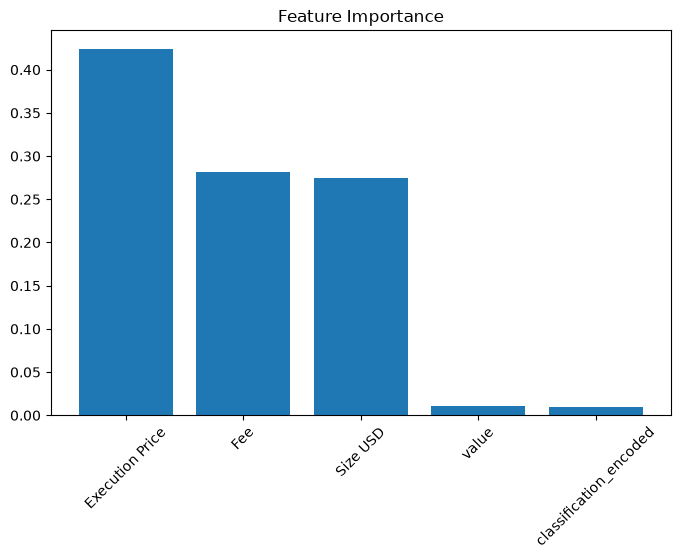

In [52]:
plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()